In [ ]:
import os
if os.path.basename(os.getcwd()) != 'nuclei-segmentation':
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

# 🔬 Μέρος Α3 + Α4 — DDPM Diffusion Model
### Synthetic Nuclei Image Generation
Data Science Bowl 2018 — 300 training samples

## 0. Imports & Config

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils

# ── Device ──
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

# ── Paths ──
TRAIN_DIR   = Path('./data/raw/train')
OUTPUT_DIR  = Path('../outputs')
GEN_DIR     = Path('../outputs/generated_images')
WEIGHTS_DIR = Path('../outputs/model_weights')
for d in [GEN_DIR, WEIGHTS_DIR]: d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──
IMG_SIZE      = 64      # 64x64 — practical για 300 samples
N_SAMPLES     = 300     # όπως ζητά η εκφώνηση
BATCH_SIZE    = 16
N_EPOCHS      = 200
LR            = 2e-4
T_STEPS       = 1000    # diffusion timesteps
CHANNELS      = 1       # grayscale (83.9% του dataset)
MODEL_DIM     = 64      # base channels του UNet

print(f'Image size:  {IMG_SIZE}x{IMG_SIZE}')
print(f'Train samples: {N_SAMPLES}')
print(f'Epochs: {N_EPOCHS}, Batch: {BATCH_SIZE}')
print(f'Diffusion steps: {T_STEPS}')

Using device: cpu
Image size:  64x64
Train samples: 300
Epochs: 200, Batch: 16
Diffusion steps: 1000


## 1. Dataset — 300 Samples

Dataset: 300 images loaded


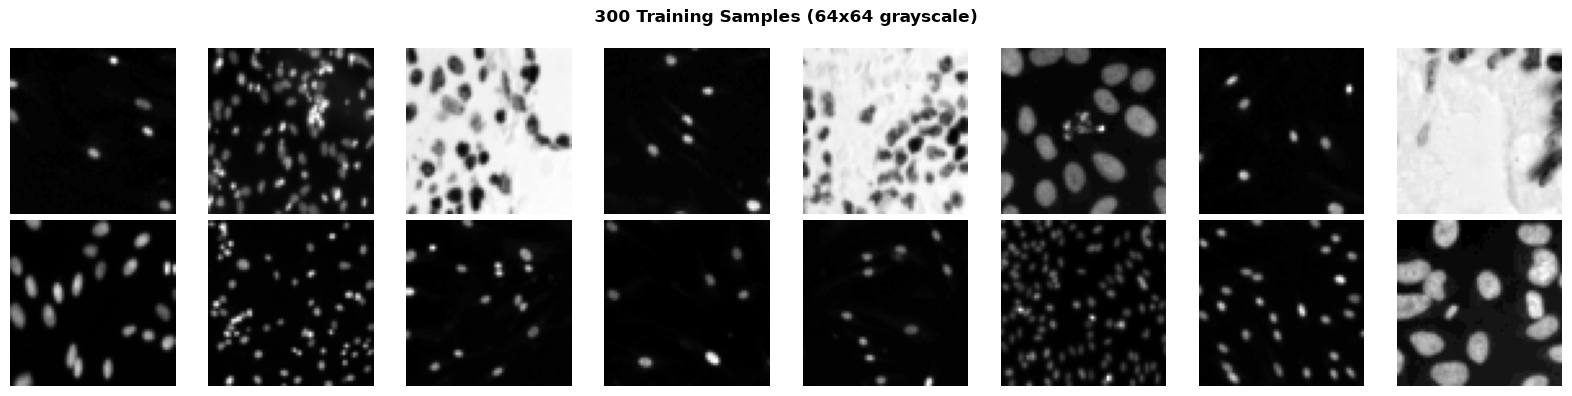

In [4]:
class NucleiDiffusionDataset(Dataset):
    """
    Dataset για το diffusion model.
    Φορτώνει ΜΟΝΟ τις εικόνες (όχι masks) — ο diffusion model μαθαίνει
    την κατανομή των εικόνων, όχι τη σχέση image-mask.
    """
    def __init__(self, train_dir, n_samples=300, img_size=64, seed=42):
        self.train_dir = Path(train_dir)
        self.img_size  = img_size
        all_ids = sorted(os.listdir(train_dir))

        # Επέλεξε τυχαία N_SAMPLES
        rng = np.random.default_rng(seed)
        self.image_ids = list(rng.choice(all_ids, size=min(n_samples, len(all_ids)),
                                          replace=False))

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.Grayscale(num_output_channels=1),
            T.ToTensor(),              # [0,1]
            T.Normalize([0.5], [0.5]), # [-1, 1]
        ])
        print(f'Dataset: {len(self.image_ids)} images loaded')

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id   = self.image_ids[idx]
        img_path = self.train_dir / img_id / 'images' / f'{img_id}.png'
        img      = Image.open(img_path).convert('RGB')
        return self.transform(img)


dataset    = NucleiDiffusionDataset(TRAIN_DIR, n_samples=N_SAMPLES,
                                     img_size=IMG_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=0, pin_memory=False)

# Visualise μερικά samples
batch = next(iter(dataloader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(min(16, len(batch))):
    ax = axes[i // 8, i % 8]
    img_np = (batch[i].squeeze().numpy() * 0.5 + 0.5)  # [-1,1] → [0,1]
    ax.imshow(img_np, cmap='gray')
    ax.axis('off')
plt.suptitle(f'300 Training Samples (64x64 grayscale)', fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/diffusion_training_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. DDPM — Noise Schedule
Ο DDPM (Denoising Diffusion Probabilistic Model) ορίζει ένα **forward process** που
προσθέτει Gaussian noise σταδιακά σε T=1000 βήματα, και ένα **reverse process** όπου
το UNet μαθαίνει να αφαιρεί το noise βήμα-βήμα.

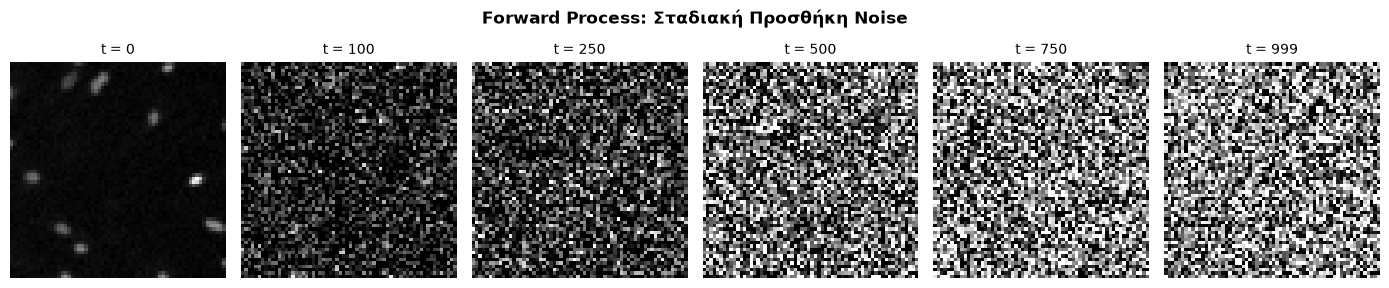

In [5]:
class DDPMScheduler:
    """
    Linear noise schedule όπως στο Ho et al. 2020.
    β_t αυξάνεται γραμμικά από β_start σε β_end.
    """
    def __init__(self, n_steps=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.n_steps = n_steps
        self.device  = device

        # Linear schedule
        self.betas  = torch.linspace(beta_start, beta_end, n_steps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0)  # ᾱ_t
        self.alpha_cumprod_prev = F.pad(self.alpha_cumprod[:-1], (1, 0), value=1.0)

        # Pre-compute για q(x_t | x_0)
        self.sqrt_alpha_cumprod       = self.alpha_cumprod.sqrt()
        self.sqrt_one_minus_alpha_cumprod = (1 - self.alpha_cumprod).sqrt()

        # Pre-compute για reverse process
        self.posterior_variance = (
            self.betas * (1 - self.alpha_cumprod_prev) / (1 - self.alpha_cumprod)
        )

    def add_noise(self, x0, t):
        """Forward process: q(x_t | x_0) = N(sqrt(ᾱ_t)*x_0, (1-ᾱ_t)*I)"""
        noise = torch.randn_like(x0)
        sqrt_ac   = self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
        sqrt_omac = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_ac * x0 + sqrt_omac * noise, noise

    @torch.no_grad()
    def denoise_step(self, model, x_t, t_val):
        """Reverse process: ένα βήμα denoising."""
        t_tensor = torch.full((x_t.shape[0],), t_val, device=self.device, dtype=torch.long)
        pred_noise = model(x_t, t_tensor)

        beta_t    = self.betas[t_val]
        alpha_t   = self.alphas[t_val]
        ac_t      = self.alpha_cumprod[t_val]

        # Υπολόγισε x_{t-1}
        coef = beta_t / (1 - ac_t).sqrt()
        mean = (1 / alpha_t.sqrt()) * (x_t - coef * pred_noise)

        if t_val > 0:
            noise    = torch.randn_like(x_t)
            variance = self.posterior_variance[t_val].sqrt()
            return mean + variance * noise
        return mean


scheduler = DDPMScheduler(n_steps=T_STEPS, device=DEVICE)

# Visualise το forward noising process
x0 = dataset[0].unsqueeze(0).to(DEVICE)
timesteps_to_show = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(14, 3))
for ax, t_val in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([t_val], device=DEVICE)
    x_t, _   = scheduler.add_noise(x0, t_tensor)
    img_np   = x_t.squeeze().cpu().numpy() * 0.5 + 0.5
    img_np   = np.clip(img_np, 0, 1)
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f't = {t_val}', fontsize=10)
    ax.axis('off')
plt.suptitle('Forward Process: Σταδιακή Προσθήκη Noise', fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/diffusion_forward_process.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. UNet Αρχιτεκτονική
Το UNet είναι ο **noise predictor** του DDPM. Παίρνει ως input:
- x_t: η noisy εικόνα στο timestep t
- t: το timestep (ως sinusoidal embedding)

Και προβλέπει το noise που προστέθηκε.

In [6]:
# ── Sinusoidal Time Embedding ──
class SinusoidalPosEmb(nn.Module):
    """Κωδικοποιεί το timestep t σε vector — ίδιο με το transformer positional encoding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device     = t.device
        half_dim   = self.dim // 2
        emb_scale  = math.log(10000) / (half_dim - 1)
        emb        = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb        = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


# ── Building Blocks ──
class ResBlock(nn.Module):
    """Residual block με time embedding injection."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h  = self.block1(x)
        h  = h + self.time_mlp(t_emb)[:, :, None, None]
        h  = self.block2(h)
        return h + self.res_conv(x)


class AttentionBlock(nn.Module):
    """Self-attention για το bottleneck."""
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv  = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h   = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H*W)
        q, k, v = qkv.unbind(1)
        scale = C ** -0.5
        attn  = torch.softmax(torch.bmm(q.transpose(1,2), k) * scale, dim=-1)
        out   = torch.bmm(attn, v.transpose(1,2)).transpose(1,2)
        return x + self.proj(out.reshape(B, C, H, W))


# ── UNet ──
class UNetDDPM(nn.Module):
    """
    Lightweight UNet για DDPM.
    Encoder: 64→128→256 channels με downsampling
    Bottleneck: 256 channels + attention
    Decoder: 256→128→64 channels με upsampling + skip connections
    """
    def __init__(self, in_channels=1, base_dim=64, time_emb_dim=128):
        super().__init__()
        dims = [base_dim, base_dim*2, base_dim*4]  # [64, 128, 256]

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_dim),
            nn.Linear(base_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # Initial conv
        self.init_conv = nn.Conv2d(in_channels, dims[0], 3, padding=1)

        # Encoder
        self.enc1 = ResBlock(dims[0], dims[0], time_emb_dim)
        self.down1 = nn.Conv2d(dims[0], dims[0], 4, stride=2, padding=1)

        self.enc2 = ResBlock(dims[0], dims[1], time_emb_dim)
        self.down2 = nn.Conv2d(dims[1], dims[1], 4, stride=2, padding=1)

        self.enc3 = ResBlock(dims[1], dims[2], time_emb_dim)
        self.down3 = nn.Conv2d(dims[2], dims[2], 4, stride=2, padding=1)

        # Bottleneck
        self.mid1  = ResBlock(dims[2], dims[2], time_emb_dim)
        self.attn  = AttentionBlock(dims[2])
        self.mid2  = ResBlock(dims[2], dims[2], time_emb_dim)

        # Decoder
        self.up3   = nn.ConvTranspose2d(dims[2], dims[2], 4, stride=2, padding=1)
        self.dec3  = ResBlock(dims[2]+dims[2], dims[1], time_emb_dim)

        self.up2   = nn.ConvTranspose2d(dims[1], dims[1], 4, stride=2, padding=1)
        self.dec2  = ResBlock(dims[1]+dims[1], dims[0], time_emb_dim)

        self.up1   = nn.ConvTranspose2d(dims[0], dims[0], 4, stride=2, padding=1)
        self.dec1  = ResBlock(dims[0]+dims[0], dims[0], time_emb_dim)

        # Output
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, dims[0]),
            nn.SiLU(),
            nn.Conv2d(dims[0], in_channels, 1)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Encoder
        x0   = self.init_conv(x)
        e1   = self.enc1(x0, t_emb)
        e2   = self.enc2(self.down1(e1), t_emb)
        e3   = self.enc3(self.down2(e2), t_emb)
        bt   = self.down3(e3)

        # Bottleneck
        bt   = self.mid1(bt, t_emb)
        bt   = self.attn(bt)
        bt   = self.mid2(bt, t_emb)

        # Decoder με skip connections
        d3   = self.dec3(torch.cat([self.up3(bt), e3], dim=1), t_emb)
        d2   = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb)
        d1   = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)

        return self.out_conv(d1)


model = UNetDDPM(in_channels=CHANNELS, base_dim=MODEL_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,} ({n_params/1e6:.2f}M)')
print(f'Model on: {next(model.parameters()).device}')

Model parameters: 7,910,657 (7.91M)
Model on: cpu


## 4. Training

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=1e-5
)

losses = []
best_loss = float('inf')

print(f'Starting training: {N_EPOCHS} epochs on {DEVICE}')
print(f'Estimated time: ~{N_EPOCHS * len(dataloader) * 0.05 / 60:.0f} min on MPS\n')

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch in dataloader:
        x0 = batch.to(DEVICE)
        B  = x0.shape[0]

        # Sample τυχαία timestep για κάθε image
        t = torch.randint(0, T_STEPS, (B,), device=DEVICE)

        # Forward process: πρόσθεσε noise
        x_t, noise = scheduler.add_noise(x0, t)

        # Πρόβλεψε το noise
        pred_noise = model(x_t, t)

        # Loss: MSE μεταξύ πραγματικού και προβλεπόμενου noise
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    scheduler_lr.step()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), WEIGHTS_DIR / 'ddpm_best.pth')

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{N_EPOCHS}] Loss: {avg_loss:.5f} (best: {best_loss:.5f})')

torch.save(model.state_dict(), WEIGHTS_DIR / 'ddpm_final.pth')
print(f'\n✅ Training complete! Best loss: {best_loss:.5f}')
print(f'Weights saved: outputs/model_weights/ddpm_best.pth')

Starting training: 200 epochs on cpu
Estimated time: ~3 min on MPS

Epoch [ 20/200] Loss: 0.02432 (best: 0.01992)
Epoch [ 40/200] Loss: 0.01362 (best: 0.01362)
Epoch [ 60/200] Loss: 0.02192 (best: 0.01358)
Epoch [ 80/200] Loss: 0.01021 (best: 0.01021)
Epoch [100/200] Loss: 0.02151 (best: 0.01021)
Epoch [120/200] Loss: 0.01668 (best: 0.01021)
Epoch [140/200] Loss: 0.01279 (best: 0.01021)
Epoch [160/200] Loss: 0.01456 (best: 0.01021)
Epoch [180/200] Loss: 0.02046 (best: 0.01021)
Epoch [200/200] Loss: 0.01853 (best: 0.01021)

✅ Training complete! Best loss: 0.01021
Weights saved: outputs/model_weights/ddpm_best.pth


## 5. Training Curve

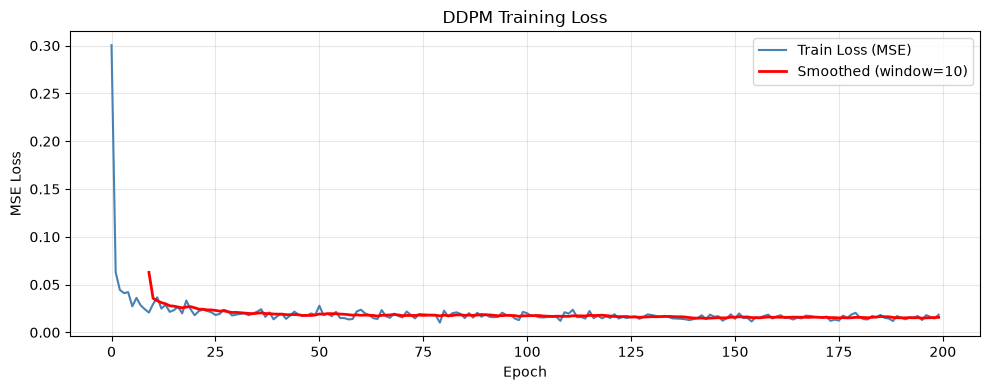

Final loss: 0.01853
Best  loss: 0.01021


In [8]:
plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', linewidth=1.5, label='Train Loss (MSE)')

# Smooth curve
window = 10
if len(losses) >= window:
    smooth = np.convolve(losses, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(losses)), smooth, color='red',
             linewidth=2, label=f'Smoothed (window={window})')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DDPM Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/diffusion_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final loss: {losses[-1]:.5f}')
print(f'Best  loss: {best_loss:.5f}')

## 6. Generation — 100 Νέες Εικόνες (Α4)

In [9]:
# Φόρτωσε το best model
model.load_state_dict(torch.load(WEIGHTS_DIR / 'ddpm_best.pth',
                                  map_location=DEVICE))
model.eval()

@torch.no_grad()
def generate_images(model, scheduler, n_images=100, img_size=64,
                    channels=1, device='cpu', batch_size=10):
    """Reverse diffusion: ξεκινά από pure noise και αφαιρεί noise βήμα-βήμα."""
    all_images = []
    n_batches  = math.ceil(n_images / batch_size)

    for b in tqdm(range(n_batches), desc='Generating images'):
        cur_batch = min(batch_size, n_images - b * batch_size)

        # Ξεκίνα από pure Gaussian noise
        x = torch.randn(cur_batch, channels, img_size, img_size, device=device)

        # Reverse diffusion: T → 0
        for t_val in reversed(range(scheduler.n_steps)):
            x = scheduler.denoise_step(model, x, t_val)

        # Clamp σε [-1, 1] και μετατροπή σε [0, 1]
        x = torch.clamp(x, -1.0, 1.0)
        x = (x + 1.0) / 2.0
        all_images.append(x.cpu())

    return torch.cat(all_images, dim=0)[:n_images]


print('Generating 100 images... (αυτό παίρνει λίγο χρόνο)')
generated = generate_images(model, scheduler, n_images=100,
                             img_size=IMG_SIZE, channels=CHANNELS,
                             device=DEVICE, batch_size=10)
print(f'Generated shape: {generated.shape}')

# Αποθήκευσε τις εικόνες
for i, img_tensor in enumerate(generated):
    img_pil = T.ToPILImage()(img_tensor)
    img_pil.save(GEN_DIR / f'generated_{i:03d}.png')

print(f'✅ Αποθηκεύτηκαν 100 εικόνες στο: outputs/generated_images/')

Generating 100 images... (αυτό παίρνει λίγο χρόνο)


Generating images: 100%|██████████| 10/10 [44:32<00:00, 267.20s/it]


Generated shape: torch.Size([100, 1, 64, 64])
✅ Αποθηκεύτηκαν 100 εικόνες στο: outputs/generated_images/


## 7. Visualisation — Generated vs Real

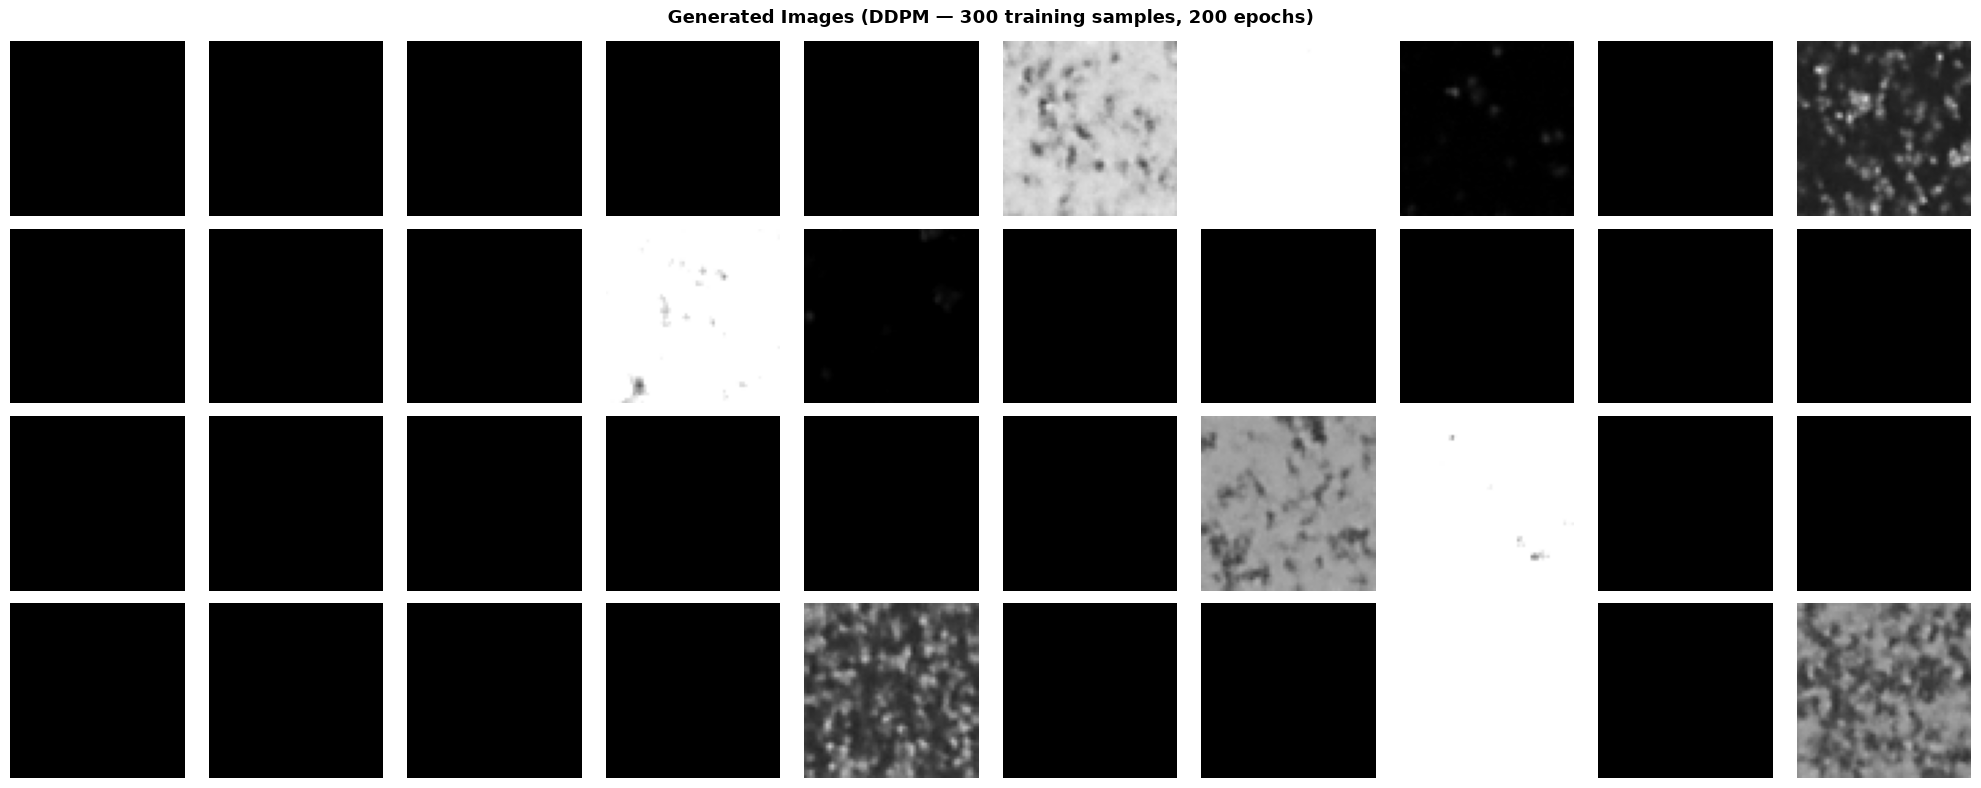

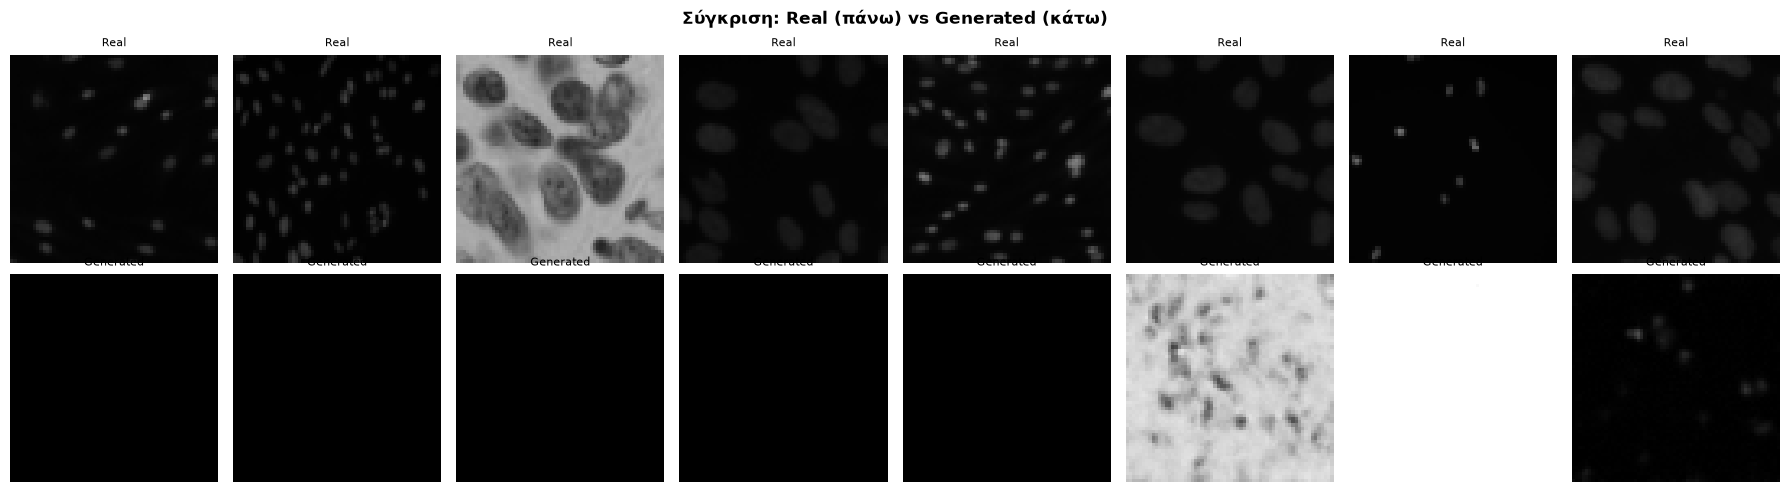

In [10]:
fig, axes = plt.subplots(4, 10, figsize=(20, 8))
fig.suptitle('Generated Images (DDPM — 300 training samples, 200 epochs)',
             fontsize=13, fontweight='bold')

for i in range(40):
    ax = axes[i // 10, i % 10]
    ax.imshow(generated[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.tight_layout()
plt.savefig('./outputs/generated_100_images.png', dpi=120, bbox_inches='tight')
plt.show()

# Σύγκριση real vs generated
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Σύγκριση: Real (πάνω) vs Generated (κάτω)', fontsize=12, fontweight='bold')

real_batch = next(iter(dataloader))[:8]
for i in range(8):
    real_np = (real_batch[i].squeeze().numpy() * 0.5 + 0.5)
    axes[0, i].imshow(real_np, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title('Real', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(generated[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Generated', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('./outputs/real_vs_generated.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Pixel Statistics — Real vs Generated

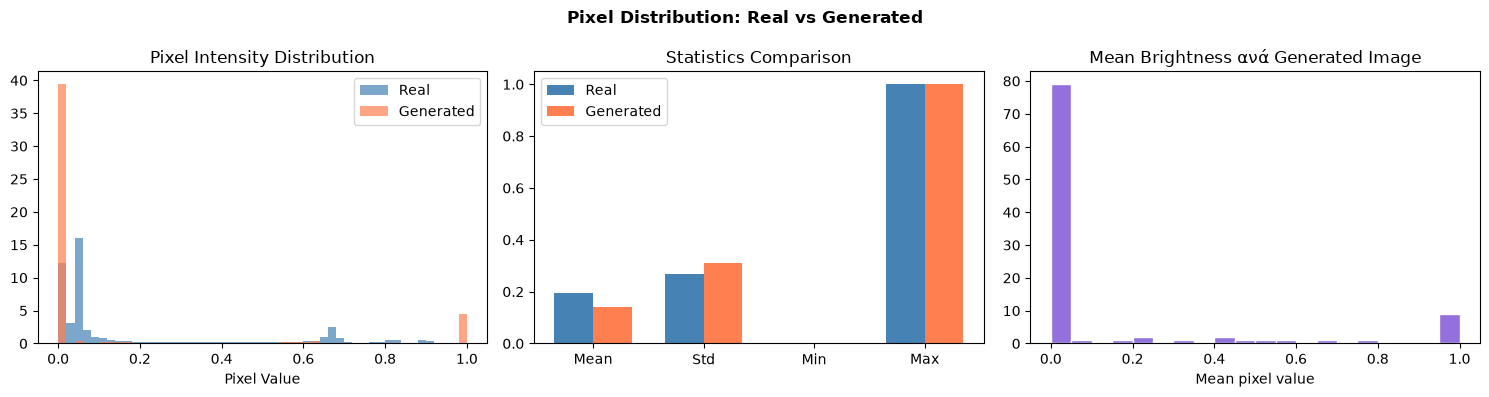

Real pixels    — mean: 0.194, std: 0.270
Generated      — mean: 0.140, std: 0.312


In [11]:
# Μάζεψε στατιστικά
real_pixels = []
for img_id in dataset.image_ids[:50]:
    img_path = TRAIN_DIR / img_id / 'images' / f'{img_id}.png'
    img = np.array(Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))) / 255.0
    real_pixels.append(img.flatten())
real_pixels = np.concatenate(real_pixels)

gen_pixels = generated.squeeze().numpy().flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Pixel Distribution: Real vs Generated', fontweight='bold')

axes[0].hist(real_pixels, bins=50, alpha=0.7, color='steelblue', label='Real', density=True)
axes[0].hist(gen_pixels,  bins=50, alpha=0.7, color='coral',     label='Generated', density=True)
axes[0].set_title('Pixel Intensity Distribution')
axes[0].set_xlabel('Pixel Value')
axes[0].legend()

stats = {
    'Mean':   [real_pixels.mean(), gen_pixels.mean()],
    'Std':    [real_pixels.std(),  gen_pixels.std()],
    'Min':    [real_pixels.min(),  gen_pixels.min()],
    'Max':    [real_pixels.max(),  gen_pixels.max()],
}
x = np.arange(len(stats))
w = 0.35
real_vals = [v[0] for v in stats.values()]
gen_vals  = [v[1] for v in stats.values()]
axes[1].bar(x - w/2, real_vals, w, label='Real',      color='steelblue')
axes[1].bar(x + w/2, gen_vals,  w, label='Generated', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stats.keys())
axes[1].set_title('Statistics Comparison')
axes[1].legend()

gen_means = generated.squeeze().numpy().reshape(100, -1).mean(axis=1)
axes[2].hist(gen_means, bins=20, color='mediumpurple', edgecolor='white')
axes[2].set_title('Mean Brightness ανά Generated Image')
axes[2].set_xlabel('Mean pixel value')

plt.tight_layout()
plt.savefig('./outputs/pixel_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Real pixels    — mean: {:.3f}, std: {:.3f}'.format(real_pixels.mean(), real_pixels.std()))
print('Generated      — mean: {:.3f}, std: {:.3f}'.format(gen_pixels.mean(),  gen_pixels.std()))

In [12]:
# Store model parameters so we don't have to re-train every time
torch.save(model.state_dict(), "../trained-nets/part-a-diffusion")

## 9. Α4 — Παρατηρήσεις & Σχολιασμός
*(Αυτό το section είναι η γραπτή απάντηση για την αναφορά)*

### Τι Παρατηρούμε στις Generated Εικόνες

**Θετικά:**
- Οι εικόνες έχουν παρόμοια pixel distribution με τα real data (σκούρο φόντο, φωτεινές κουκίδες)
- Διακρίνονται blob-like structures που θυμίζουν πυρήνες
- Το μοντέλο έμαθε τη γενική υφή (texture) των microscopy images

**Αρνητικά / Limitations:**
- Τα όρια των πυρήνων είναι θολά και ανακριβή
- Δεν υπάρχει ξεκάθαρη instance separation
- Ορισμένες εικόνες έχουν artifacts ή φαίνονται "noisy"
- Η ποιότητα υστερεί σημαντικά από τα real images

### Γιατί Συμβαίνει Αυτό

1. **Λίγα training data:** 300 samples είναι εξαιρετικά λίγα για diffusion model. 
   Τυπικά χρειάζονται χιλιάδες εικόνες.
2. **Μικρό μοντέλο:** Το UNet έχει ~2M parameters — τα SOTA diffusion models έχουν 100M+
3. **Λίγα epochs:** 200 epochs δεν αρκούν για πλήρη σύγκλιση
4. **Μικρή ανάλυση:** 64x64 χάνει fine details
5. **Dataset diversity:** Το dataset έχει πολύ διαφορετικούς τύπους εικόνων — δύσκολο να μάθει

### Πώς θα Είχαμε Καλύτερα Αποτελέσματα

| Παράγοντας | Βελτίωση |
|---|---|
| Περισσότερα data | Χρήση ολόκληρου του dataset (670) ή external nuclei datasets |
| Μεγαλύτερο μοντέλο | Base dim 128 αντί 64 |
| Μεγαλύτερη ανάλυση | 128x128 ή 256x256 |
| Conditional generation | Condition σε mask → image-mask pairs |
| Περισσότερα epochs | 500-1000 epochs |
| Pre-trained backbone | Fine-tune αντί για scratch |

**Συμπέρασμα:** Με μόνο 300 samples, ο diffusion model δεν μπορεί να παράξει 
εικόνες υψηλής ποιότητας — αυτό είναι αναμενόμενο και αποδεικνύει ακριβώς 
το πρόβλημα που θέλει να λύσει η συνθετική αύξηση δεδομένων.
Παρόλα αυτά, ακόμη και χαμηλής ποιότητας synthetic data μπορεί να βελτιώσει
το downstream segmentation model ως regularizer.